# NFIP Single-Residence Severity — Gamma GLM

A severity model for single-family residential NFIP claims, restricted to variables
observable at underwriting. Response is inflation-trended **assessed building
damage**, conditional on a claim.

Runs top to bottom. Every section depends only on sections above it.

| § | Contents |
|---|---|
| 1 | Load, re-merge NOAA coastal classification, validate |
| 2 | Inflation trending and date-integrity filter |
| 3 | Collinearity: coastal flags vs flood zone |
| 4 | Model frame, specification, train/test split |
| 5 | OLS baseline (motivates the GLM) |
| 6 | Gamma GLM, log link — headline model |
| 7 | Relativities, lift, calibration, rating spread |
| 8 | Sensitivity: home-value imputation |
| 9 | Other severity distributions |
| 10 | Export |

### Specification decisions

- **Log link, passed explicitly.** Multiplicative effects, non-negative fitted mean.
  statsmodels defaults Gamma to the inverse link, which is numerically fragile here.
- **`method='newton'` with log-OLS starting values.** IRLS limit-cycles on this
  design; Newton has no damping, so an uninformed start can overflow `exp()`.
- **Home value on a log scale, per \$100k.** Chosen on AIC and holdout RMSE against
  the linear form (§9). The coefficient is an *elasticity*: the effect of doubling
  home value is `2**beta`, not `exp(beta)`.
- **No scaler.** Unit choice alone fixes conditioning and keeps coefficients readable.
- **One consolidated elevation-missingness flag.** The three component flags agree
  on 99%+ of rows.
- **Underwriting-time variables only.** `waterDepth`, `causeOfDamage`, and
  `floodEvent` are present in the source file and would improve fit substantially,
  but are post-loss information and unobservable when a policy is priced.
- **Response is assessed damage, not paid loss**, so the \$250,000 NFIP building
  limit does not censor the upper tail.

### Data placement

Paths are set in the configuration cell in section 1. This notebook expects
`model_ready_nfip.parquet` (produced by the wrangling notebook) and
`county_classification.csv` (in this repo) under `REPO/data/processed/`. Change
`REPO` to match your environment; the Colab mount can be removed if running
locally.

### Coastal classification

The parquet is written with an earlier coastal lookup, so section 1 drops those
columns and re-merges from `county_classification.csv`, which is built from
NOAA's *Defining Coastal Counties* reference (2010 boundaries). The definitions
are nested: 452 shoreline counties sit within 769 watershed counties, and
counties absent from the file are non-coastal. An assert on the shoreline count
and a spot-check of unambiguously coastal counties both run before modelling.

## 1. Setup, load, and re-merge the rebuilt coastal classification

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.families import links
import matplotlib.pyplot as plt
import patsy, os

from google.colab import drive
drive.mount('/content/drive')

REPO      = '/content/drive/MyDrive/Programming/nfip/Single-Residence Severity'
IN_PQ     = f'{REPO}/data/processed/model_ready_nfip.parquet'
COUNTY_CSV = f'{REPO}/data/processed/county_classification.csv'
OUT_DIR   = f'{REPO}/outputs'
os.makedirs(OUT_DIR, exist_ok=True)

RANDOM_STATE = 808
TEST_FRAC    = 0.20

df = pd.read_parquet(IN_PQ)
print(f'Loaded {len(df):,} records x {df.shape[1]} columns.')

# ---- Replace the old miscoded flags with the rebuilt NOAA classification ----
# The parquet was written before county_classification.csv was rebuilt, so its
# SHORELINE_FLAG / WATERSHED_FLAG columns are the broken ones. Drop and re-merge.
# NOAA's definitions are NESTED: every county in the file is a coastal WATERSHED
# county (769), and 452 of those are also coastal SHORELINE counties. Counties
# absent from the file are non-coastal and get 0 for both.
df = df.drop(columns=[c for c in ('SHORELINE_FLAG', 'WATERSHED_FLAG') if c in df.columns])

county = pd.read_csv(COUNTY_CSV, dtype={'FIPS': str})
assert county['SHORELINE_FLAG'].sum() == 452, (
    f"Expected 452 NOAA shoreline counties, got {county['SHORELINE_FLAG'].sum()} -- "
    "wrong county_classification.csv?")

df = df.merge(county[['FIPS', 'SHORELINE_FLAG', 'WATERSHED_FLAG']],
              how='left', on='FIPS')
df['SHORELINE_FLAG'] = df['SHORELINE_FLAG'].fillna(0).astype(int)
df['WATERSHED_FLAG'] = df['WATERSHED_FLAG'].fillna(0).astype(int)

# Spot-check against counties whose coastal status is not in dispute
CHECK = {'01003': 'Baldwin AL', '34029': 'Ocean NJ', '45019': 'Charleston SC',
         '12086': 'Miami-Dade FL', '48201': 'Harris TX'}
fails = 0
for fips, name in CHECK.items():
    sub = df.loc[df['FIPS'] == fips, 'SHORELINE_FLAG']
    ok = len(sub) == 0 or (sub == 1).all()
    fails += (not ok)
    status = 'OK' if ok else 'FAIL'
    n = len(sub)
    print(f'  [{status}] {name:<16} ({n:,} claims) SHORELINE={sub.iloc[0] if n else "n/a"}')
assert fails == 0, 'Rebuilt classification failed spot-checks'

print('\nClaim share by flag:')
print(df[['SHORELINE_FLAG', 'WATERSHED_FLAG']].mean().round(4))
print('\nShoreline claim rate, largest states:')
print(df.groupby('STATE')['SHORELINE_FLAG'].agg(['mean', 'count'])
        .sort_values('count', ascending=False).head(8).round(3))

Mounted at /content/drive
Loaded 290,873 records x 43 columns.
  [OK] Baldwin AL       (1,765 claims) SHORELINE=1
  [OK] Ocean NJ         (6,678 claims) SHORELINE=1
  [OK] Charleston SC    (2,212 claims) SHORELINE=1
  [OK] Miami-Dade FL    (1,943 claims) SHORELINE=1
  [OK] Harris TX        (33,921 claims) SHORELINE=1

Claim share by flag:
SHORELINE_FLAG    0.7411
WATERSHED_FLAG    0.8296
dtype: float64

Shoreline claim rate, largest states:
        mean  count
STATE              
TX     0.792  70747
FL     0.965  66784
LA     0.684  34629
NJ     0.910  20354
NY     0.916  15960
NC     0.694  13283
SC     0.778   7732
PA     0.082   5016


## 2. Inflation adjustment and date-integrity filter

In [2]:
import pandas_datareader.data as web
import datetime

# PPI: construction inputs. Appropriate for trending repair/rebuild costs.
FRED_SERIES = 'WPUIP2311001'
EXPOSURE_START = 2011   # matches the originalNBDate filter in the wrangling notebook

fred = web.DataReader(FRED_SERIES, 'fred',
                      datetime.datetime(1990, 1, 1),
                      datetime.datetime.today())
annual = fred.resample('YE').mean()
annual.index = annual.index.year
trend = annual[FRED_SERIES].to_dict()

baseline_date = fred.index.max()
baseline = float(fred.loc[baseline_date, FRED_SERIES])
print(f'Baseline (current cost level): {baseline_date:%Y-%m} = {baseline:.2f}')

# Losses before 2011 predate their own policy (population is originalNBDate >= 2011)
# -- corrupt date fields, dropped rather than trended.
loss_years = df['yearOfLoss'].dropna()
pre = (loss_years < EXPOSURE_START)
print(f'Losses before exposure period: {pre.sum():,} ({pre.mean()*100:.2f}%) -- dropped')

before = len(df)
df = df[(df['yearOfLoss'] >= EXPOSURE_START) & df['yearOfLoss'].notna()].copy()
print(f'Remaining: {len(df):,}')

loss_years = sorted(df['yearOfLoss'].unique())
uncovered = [int(y) for y in loss_years if y not in trend]
assert not uncovered, f'Loss years {uncovered} lack a trend factor'

factor = df['yearOfLoss'].map(lambda y: baseline / trend[y])
df['damage_trended'] = df['buildingDamageAmount'] * factor
print(f'Trend factors: {factor.min():.3f} - {factor.max():.3f}')
print(f"Trended damage: median {df['damage_trended'].median():,.0f}, "
      f"mean {df['damage_trended'].mean():,.0f}")

Baseline (current cost level): 2026-07 = 344.86
Losses before exposure period: 3,532 (1.21%) -- dropped
Remaining: 287,341
Trend factors: 1.019 - 1.702
Trended damage: median 37,270, mean 70,611


## 3. Collinearity: coastal flags vs flood zone

Both encode "closeness to dangerous water," so the question is whether they carry
distinct information. Flood zone is a **parcel-level FEMA hazard rating**; the
coastal flags are **county-level NOAA geography**. NOAA's definitions are nested —
every shoreline county is also a watershed county.

In [3]:
ct = pd.crosstab(df['floodZoneCurrent'], df['SHORELINE_FLAG'], margins=True)
print('Counts:')
print(ct)
print('\nShoreline share within each zone:')
print(pd.crosstab(df['floodZoneCurrent'], df['SHORELINE_FLAG'], normalize='index')
        .round(3))

# Cramer's V: association strength for two categoricals, 0 (none) to 1 (identical).
from scipy.stats import chi2_contingency
tab = pd.crosstab(df['floodZoneCurrent'], df['SHORELINE_FLAG'])
chi2 = chi2_contingency(tab)[0]
n = tab.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(tab.shape) - 1)))
print(f"\nCramer's V (zone vs shoreline): {cramers_v:.3f}")

tab_w = pd.crosstab(df['floodZoneCurrent'], df['WATERSHED_FLAG'])
chi2_w = chi2_contingency(tab_w)[0]
v_w = np.sqrt(chi2_w / (tab_w.values.sum() * (min(tab_w.shape) - 1)))
print(f"Cramer's V (zone vs watershed): {v_w:.3f}")

# Shoreline is a subset of watershed by construction -- report their overlap too.
print(f"\nShoreline x watershed crosstab (shoreline should imply watershed):")
print(pd.crosstab(df['SHORELINE_FLAG'], df['WATERSHED_FLAG']))

print('\nRule of thumb: V < 0.3 weak, 0.3-0.6 moderate, > 0.8 near-redundant.')
print('Moderate association is expected and fine for a GLM -- coefficients then')
print('measure each effect NET of the other. Near-redundancy (V > 0.8) would mean')
print('picking one. The design-matrix condition number in section 4 is the final')
print('arbiter: it measures joint, not just pairwise, redundancy.')

Counts:
SHORELINE_FLAG             0       1     All
floodZoneCurrent                            
A Zones                40399  127728  168127
Unknown                13139   28037   41176
V Zones                    0    5181    5181
Zone B & X (shaded)      600    3263    3863
Zone C & X (unshaded)  20373   48621   68994
All                    74511  212830  287341

Shoreline share within each zone:
SHORELINE_FLAG             0      1
floodZoneCurrent                   
A Zones                0.240  0.760
Unknown                0.319  0.681
V Zones                0.000  1.000
Zone B & X (shaded)    0.155  0.845
Zone C & X (unshaded)  0.295  0.705

Cramer's V (zone vs shoreline): 0.112
Cramer's V (zone vs watershed): 0.103

Shoreline x watershed crosstab (shoreline should imply watershed):
WATERSHED_FLAG      0       1
SHORELINE_FLAG               
0               48925   25586
1                   0  212830

Rule of thumb: V < 0.3 weak, 0.3-0.6 moderate, > 0.8 near-redundant.
Moderate a

## 4. Model frame and train/test split

In [4]:
df['home_value_100k'] = df['median_home_value'] / 1e5
df['is_county_imputed'] = (df['imputation'] == 'county').astype(int)

MODEL_VARS = [
    'damage_trended',
    'elevationDifference', 'numberOfFloorsInTheInsuredBuilding',
    'home_value_100k', 'buildingAge',
    'floodZoneCurrent', 'basementEnclosureCrawlspaceType', 'obstructionType',
    'primaryResidenceIndicator', 'rentalPropertyIndicator',
    'elevatedBuildingIndicator',
    'is_mobile_home', 'is_elev_missing', 'is_home_value_topcoded',
    'SHORELINE_FLAG', 'WATERSHED_FLAG', 'is_county_imputed',
]

before = len(df)
model_df = df[MODEL_VARS].dropna().copy()
print(f'Complete cases: {len(model_df):,} of {before:,} '
      f'({len(model_df)/before*100:.1f}%)')

# Home value enters on a LOG scale. With a log link on the response as well, the
# relationship is a power law: mu proportional to home_value^beta. Beta is an
# elasticity, so the effect of DOUBLING home value is 2**beta, not exp(beta).
# Chosen over the linear form on AIC (5,320,106 vs 5,320,639) and holdout RMSE.
# The linear form implied each additional $100k added a fixed 4.1%, which would
# make a $2m home carry twenty times the loading of a $100k home.
#
# baseFloodElevation / lowestAdjacentGrade / lowestFloorElevation excluded: ~65%
# zero-filled and near-collinear with elevationDifference given is_elev_missing.
# WATERSHED_FLAG is the broader NOAA set containing SHORELINE_FLAG, so its
# coefficient reads as "coastal watershed but NOT shoreline" once both are in.

assert (model_df['home_value_100k'] > 0).all(), \
    'home_value_100k has non-positive values -- log would produce -inf'

PREDICTORS = (
    "elevationDifference + numberOfFloorsInTheInsuredBuilding + "
    "np.log(home_value_100k) + buildingAge + "
    "C(floodZoneCurrent, Treatment(reference='Zone C & X (unshaded)')) + "
    "C(basementEnclosureCrawlspaceType, Treatment(reference='None')) + "
    "C(obstructionType, Treatment(reference='Free of Obstruction')) + "
    "C(primaryResidenceIndicator, Treatment(reference='False')) + "
    "C(rentalPropertyIndicator, Treatment(reference='False')) + "
    "C(elevatedBuildingIndicator, Treatment(reference='False')) + "
    "is_mobile_home + is_elev_missing + is_home_value_topcoded + "
    "SHORELINE_FLAG + WATERSHED_FLAG + is_county_imputed"
)
FORMULA     = f'damage_trended ~ {PREDICTORS}'
FORMULA_LOG = f'np.log(damage_trended) ~ {PREDICTORS}'

# Guard: FORMULA is built from PREDICTORS, so any edit must appear in both.
# Applying a transform to PREDICTORS after FORMULA is built fails silently -- the
# GLMs keep fitting the old term while PREDICTORS claims otherwise, reproducing
# identical results across a supposedly changed specification.
assert 'np.log(home_value_100k)' in FORMULA, 'FORMULA out of sync with PREDICTORS'
assert 'home_value_100k +' not in FORMULA, 'Bare linear home_value_100k still in FORMULA'
print('Specification check: home value is on the log scale in PREDICTORS and FORMULA.')

for c in ('floodZoneCurrent', 'basementEnclosureCrawlspaceType', 'obstructionType'):
    vc = model_df[c].value_counts()
    assert vc.min() >= 500, f'{c} level "{vc.idxmin()}" has only {vc.min()} records'
print('Categorical cell sizes OK (all >= 500).')

X_chk = patsy.dmatrix(PREDICTORS, model_df, return_type='dataframe')
cond = np.linalg.cond(X_chk.values)
print(f'Design matrix: {X_chk.shape[1]} cols, '
      f'rank {np.linalg.matrix_rank(X_chk.values)}, condition number {cond:.3g}')
assert cond < 1e5, 'Design matrix poorly conditioned'

test  = model_df.sample(frac=TEST_FRAC, random_state=RANDOM_STATE)
train = model_df.drop(test.index)
train_pos = train[train['damage_trended'] > 0].copy()
test_pos  = test[test['damage_trended'] > 0].copy()
print(f'\nTrain: {len(train):,} ({len(train_pos):,} positive)   '
      f'Test: {len(test):,} ({len(test_pos):,} positive)')

Complete cases: 285,935 of 287,341 (99.5%)
Specification check: home value is on the log scale in PREDICTORS and FORMULA.
Categorical cell sizes OK (all >= 500).
Design matrix: 24 cols, rank 24, condition number 739

Train: 228,748 (219,634 positive)   Test: 57,187 (54,955 positive)


## 5. OLS baseline

The naive benchmark. Two failures motivate the GLM: effects are additive (a basement
subtracts the same dollars from a \$40k risk as a \$400k one), and predictions can go
negative.

In [5]:
ols = smf.ols(FORMULA, data=train_pos).fit()
print(f'OLS R-squared: {ols.rsquared:.4f}   adj: {ols.rsquared_adj:.4f}')

ols_pred = ols.predict(test_pos)
n_neg = (ols_pred < 0).sum()
print(f'Negative predicted damages on holdout: {n_neg:,} of {len(test_pos):,} '
      f'({n_neg/len(test_pos)*100:.2f}%) -- impossible values, the structural '
      f'failure of an identity link on severity')

print('\nLargest OLS coefficients (dollars, additive):')
print(ols.params.reindex(ols.params.abs().sort_values(ascending=False).index)
      .head(8).round(0).to_string())

OLS R-squared: 0.0937   adj: 0.0936
Negative predicted damages on holdout: 700 of 54,955 (1.27%) -- impossible values, the structural failure of an identity link on severity

Largest OLS coefficients (dollars, additive):
Intercept                                                                                   67655.0
C(basementEnclosureCrawlspaceType, Treatment(reference='None'))[T.Finished Basement]       -49552.0
C(elevatedBuildingIndicator, Treatment(reference='False'))[T.True]                         -45282.0
C(basementEnclosureCrawlspaceType, Treatment(reference='None'))[T.Unfinished Basement]     -37911.0
C(basementEnclosureCrawlspaceType, Treatment(reference='None'))[T.Subgrade Crawlspace]     -32622.0
is_mobile_home                                                                             -23639.0
WATERSHED_FLAG                                                                              12797.0
C(floodZoneCurrent, Treatment(reference='Zone C & X (unshaded)'))[T.Zone B & X 

## 6. Gamma GLM (log link) — headline model

Gamma: variance $\propto \mu^2$, i.e. constant coefficient of variation — the
empirical signature of claim severity. Log link: $e^\beta$ reads as a rating
relativity.

In [6]:
def _converged(res):
    """A fit that diverged to NaN can still report converged=True -- treat NaN as
    failure regardless of the flag."""
    if not np.isfinite(res.deviance) or res.params.isna().any():
        return False
    c = getattr(res, 'converged', None)
    if c is not None:
        return bool(c)
    rv = getattr(res, 'mle_retvals', None)
    return bool(rv.get('converged')) if isinstance(rv, dict) else None

def _iterations(res):
    fh = getattr(res, 'fit_history', None)
    if not isinstance(fh, dict):
        return '?'
    it = fh.get('iteration', '?')
    if isinstance(it, (list, tuple, np.ndarray)):
        return len(it) if len(it) else '?'
    return it

def fit_glm(name, family, data, formula=None, maxiter=100, start_params=None):
    formula = formula or FORMULA
    res = smf.glm(formula=formula, data=data, family=family).fit(
        method='newton', maxiter=maxiter, start_params=start_params)
    conv, iters = _converged(res), _iterations(res)
    flag = '' if conv else '   <-- DID NOT CONVERGE, do not interpret'
    print(f'{name:<22} converged={str(conv):<7} iters={str(iters):<5} '
          f'deviance={res.deviance:,.0f}  loglik={res.llf:,.0f}  '
          f'scale={res.scale:.4f}{flag}')
    return res

LOG = links.Log()
fits = {}

# Newton has no damping; log-OLS provides starting values in log-mean space.
ols_start = smf.ols(f'np.log(damage_trended.clip(lower=1)) ~ {PREDICTORS}',
                    data=train_pos).fit()

fits['Gamma'] = fit_glm('Gamma', sm.families.Gamma(link=LOG), train_pos,
                        start_params=ols_start.params)
GAMMA = fits['Gamma']
print()
print(GAMMA.summary())

null_gamma = smf.glm('damage_trended ~ 1', data=train_pos,
                     family=sm.families.Gamma(link=LOG)).fit(method='newton')
d2 = 1 - GAMMA.deviance / null_gamma.deviance
print(f'\nD-squared (deviance explained): {d2:.4f}   '
      f'(OLS R-squared for comparison: {ols.rsquared:.4f})')

Gamma                  converged=True    iters=8     deviance=334,916  loglik=-2,660,034  scale=1.6313

                 Generalized Linear Model Regression Results                  
Dep. Variable:         damage_trended   No. Observations:               219634
Model:                            GLM   Df Residuals:                   219610
Model Family:                   Gamma   Df Model:                           23
Link Function:                    Log   Scale:                          1.6313
Method:                        newton   Log-Likelihood:            -2.6600e+06
Date:                Thu, 27 Aug 2026   Deviance:                   3.3492e+05
Time:                        18:30:44   Pearson chi2:                 3.58e+05
No. Iterations:                     8   Pseudo R-squ. (CS):             0.1009
Covariance Type:            nonrobust                                         
                                                                                               coef    std

## 7. Relativities, calibration, and rating spread

--- Relativities (exp(coef)) ---
                                                      coefficient  relativity  std_err  p_value   rel_lower   rel_upper
Intercept                                                 11.1056  66543.4262   0.0302   0.0000  62719.3194  70600.6955
WATERSHED_FLAG                                             0.1935      1.2135   0.0115   0.0000      1.1864      1.2412
is_home_value_topcoded                                     0.1781      1.1950   0.0272   0.0000      1.1329      1.2605
floodZoneCurrent: Zone B & X (shaded)                      0.1744      1.1905   0.0242   0.0000      1.1353      1.2484
floodZoneCurrent: A Zones                                  0.1448      1.1558   0.0078   0.0000      1.1383      1.1735
np.log(home_value_100k)                                    0.1380      1.1480   0.0045   0.0000      1.1379      1.1581
primaryResidenceIndicator: True                            0.1246      1.1327   0.0078   0.0000      1.1156      1.1500
floodZo

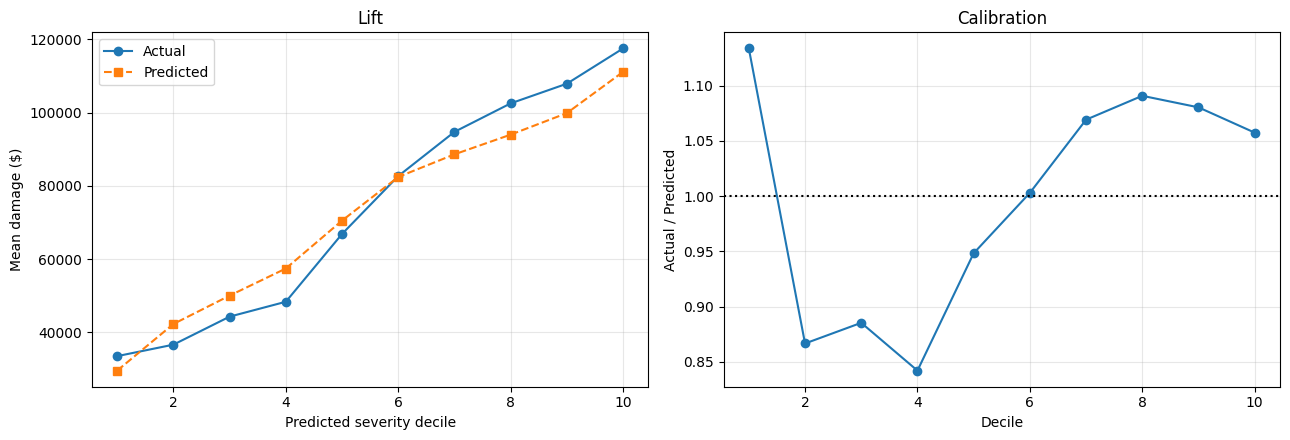

Calibration slope (log-log): 1.1875  (1.00 = correct spread; > 1 = predictions too compressed)
Holdout bias: -1.25%

--- Predicted severity across the test book ---
  P   1  $21,183
  P  10  $37,703
  P  50  $78,102
  P  90  $103,630
  P  99  $119,429
  P99/P1 ratio:  5.6x
  P90/P10 ratio: 2.7x


In [7]:
# ---- Relativities ----
rel = pd.DataFrame({'coefficient': GAMMA.params,
                    'relativity': np.exp(GAMMA.params),
                    'std_err': GAMMA.bse, 'p_value': GAMMA.pvalues})
rel['rel_lower'] = np.exp(GAMMA.conf_int()[0])
rel['rel_upper'] = np.exp(GAMMA.conf_int()[1])
rel.index = (rel.index
             .str.replace(r"C\((\w+), Treatment\(reference='[^']*'\)\)\[T\.",
                          r"\1: ", regex=True)
             .str.replace(r"\]$", "", regex=True))
print('--- Relativities (exp(coef)) ---')
print(rel.sort_values('relativity', ascending=False).round(4).to_string())

# ---- Holdout lift and calibration ----
mu_te = GAMMA.predict(test_pos).values
y_te  = test_pos['damage_trended'].values
t = pd.DataFrame({'pred': mu_te, 'actual': y_te})
t['decile'] = pd.qcut(t['pred'], 10, labels=False, duplicates='drop') + 1
lt = t.groupby('decile').agg(n=('actual', 'size'), mean_pred=('pred', 'mean'),
                             mean_actual=('actual', 'mean'))
lt['ratio'] = lt['mean_actual'] / lt['mean_pred']
print('\n--- Holdout lift (test_pos) ---')
print(lt.round(3).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(lt.index, lt['mean_actual'], 'o-', label='Actual')
ax[0].plot(lt.index, lt['mean_pred'], 's--', label='Predicted')
ax[0].set_xlabel('Predicted severity decile'); ax[0].set_ylabel('Mean damage ($)')
ax[0].set_title('Lift'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(lt.index, lt['ratio'], 'o-')
ax[1].axhline(1.0, color='k', ls=':')
ax[1].set_xlabel('Decile'); ax[1].set_ylabel('Actual / Predicted')
ax[1].set_title('Calibration'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

cal = smf.ols('np.log(y) ~ np.log(mu)',
              data=pd.DataFrame({'y': y_te, 'mu': mu_te})).fit()
slope = cal.params['np.log(mu)']
print(f'Calibration slope (log-log): {slope:.4f}  '
      f'(1.00 = correct spread; > 1 = predictions too compressed)')
print(f'Holdout bias: {(mu_te.mean()/y_te.mean()-1)*100:+.2f}%')

# ---- Rating spread across the book ----
q = pd.Series(mu_te).quantile([.01, .10, .50, .90, .99])
print('\n--- Predicted severity across the test book ---')
for lab, v in q.items():
    print(f'  P{lab*100:>4.0f}  ${v:,.0f}')
print(f'  P99/P1 ratio:  {q.loc[.99]/q.loc[.01]:.1f}x')
print(f'  P90/P10 ratio: {q.loc[.90]/q.loc[.10]:.1f}x')

## 8. Sensitivity: home-value imputation

`median_home_value` was filled at three levels of coarseness — direct block-group
match, tract median, or county median. County-level imputation replaces block-group
variation with a single county figure, which flattens the predictor for those
records and attenuates its coefficient. This section quantifies the damage.

In [8]:
# ============================================================
#  Sensitivity: how much did home-value imputation affect results?
# ============================================================
# median_home_value was filled at three levels of increasing coarseness:
#   'none'   -- block group matched directly in the ACS grid
#   'tract'  -- median of the surrounding census tract
#   'county' -- median of the whole county  (coarsest, most suspect)
# Two questions: (1) do imputed records differ systematically in severity, and
# (2) would the coefficients change if we dropped them?
#
# NOTE: is_county_imputed is in the main model, but it must be REMOVED for the
# analyses below. The refit subsets are defined by that same variable, so within
# 'direct matches only' it is constant 0 -- perfectly collinear with the
# intercept, which makes the design matrix singular. C(imputation)[T.county] is
# likewise identical to it.
IMP_TERM = 'is_county_imputed'
P_BASE = (PREDICTORS.replace(f' + {IMP_TERM}', '')
                    .replace(f'{IMP_TERM} + ', '')
                    .replace(IMP_TERM, '').strip().rstrip('+').strip())
F_BASE = f'damage_trended ~ {P_BASE}'
assert IMP_TERM not in F_BASE, 'is_county_imputed not stripped from sensitivity formula'
print(f'Sensitivity formula excludes {IMP_TERM} (collinear within subsets).\n')

imp = df.loc[model_df.index, 'imputation'].fillna('none')
model_df_i  = model_df.assign(imputation=imp)
train_pos_i = model_df_i.loc[train_pos.index]
test_pos_i  = model_df_i.loc[test_pos.index]

print('--- Imputation source ---')
share = train_pos_i['imputation'].value_counts()
print(pd.DataFrame({'n': share, 'pct': (share / len(train_pos_i) * 100).round(2)}))

print('\n--- Raw severity and home value by imputation source ---')
print(train_pos_i.groupby('imputation').agg(
    n=('damage_trended', 'size'),
    median_damage=('damage_trended', 'median'),
    mean_damage=('damage_trended', 'mean'),
    median_home_100k=('home_value_100k', 'median'),
    sd_home_100k=('home_value_100k', 'std'),
).round(2).to_string())
print('\nLower dispersion in the county group means the imputation flattened the')
print('variable for those records, attenuating its coefficient toward zero.')

# ---- 1. Is imputation source itself predictive? ----
F_IMP = F_BASE + " + C(imputation, Treatment(reference='none'))"
P_IMP = P_BASE + " + C(imputation, Treatment(reference='none'))"
start_imp = smf.ols(f'np.log(damage_trended.clip(lower=1)) ~ {P_IMP}',
                    data=train_pos_i).fit()
g_imp = smf.glm(F_IMP, data=train_pos_i,
                family=sm.families.Gamma(link=LOG)).fit(
    method='newton', maxiter=100, start_params=start_imp.params)

print('\n--- Is imputation source itself predictive of severity? ---')
imp_terms = [t for t in g_imp.params.index if 'imputation' in t]
print(pd.DataFrame({'relativity': np.exp(g_imp.params[imp_terms]),
                    'p_value': g_imp.pvalues[imp_terms]}).round(4).to_string())
print('Far from 1.00 means imputed records differ systematically -- the fill is')
print('carrying signal rather than just filling a hole.')

# ---- 2. Do coefficients move if imputed records are dropped? ----
sub_none = train_pos_i[train_pos_i['imputation'] == 'none']
sub_notc = train_pos_i[train_pos_i['imputation'] != 'county']
print(f"\nDirect matches only:      {len(sub_none):,} rows "
      f"({len(sub_none)/len(train_pos_i)*100:.1f}% of train)")
print(f"Excluding county-imputed: {len(sub_notc):,} rows")

def refit(data, label):
    s = smf.ols(f'np.log(damage_trended.clip(lower=1)) ~ {P_BASE}', data=data).fit()
    r = smf.glm(F_BASE, data=data, family=sm.families.Gamma(link=LOG)).fit(
        method='newton', maxiter=100, start_params=s.params)
    ok = np.isfinite(r.deviance) and not r.params.isna().any()
    print(f'  {label:<28} ok={ok}  n={int(r.nobs):,}  deviance={r.deviance:,.0f}')
    return r

# Baseline on the SAME formula, so the comparison is like-for-like.
g_full = refit(train_pos_i, 'full train (base formula)')
g_none = refit(sub_none,    'direct matches only')
g_notc = refit(sub_notc,    'excl. county-imputed')

cmp = pd.DataFrame({'full': g_full.params, 'no_county': g_notc.params,
                    'direct_only': g_none.params, 'se_full': g_full.bse})
cmp['shift_direct_in_SE'] = (cmp['direct_only'] - cmp['full']).abs() / cmp['se_full']
cmp['rel_full']   = np.exp(cmp['full'])
cmp['rel_direct'] = np.exp(cmp['direct_only'])
cmp = cmp.sort_values('shift_direct_in_SE', ascending=False)
cmp.index = (cmp.index
             .str.replace(r"C\((\w+), Treatment\(reference='[^']*'\)\)\[T\.",
                          r"\1: ", regex=True)
             .str.replace(r"\]$", "", regex=True))

print('\n--- Coefficient sensitivity (sorted by movement, in standard errors) ---')
print(cmp[['rel_full', 'rel_direct', 'shift_direct_in_SE']].head(12).round(4).to_string())
print('\nshift_direct_in_SE is |coefficient change| divided by its standard error.')
print('Under 1.0 is ordinary sampling noise. Above ~2.0 means the imputed records')
print('were materially influencing that coefficient.')
print(f"\nCoefficients moving more than 2 SE: {(cmp['shift_direct_in_SE'] > 2).sum()} "
      f"of {len(cmp)}")

hv = 'np.log(home_value_100k)'
if hv in cmp.index:
    row = cmp.loc[hv]
    print(f"\nHome value elasticity: {row['full']:.4f} (full) vs "
          f"{row['direct_only']:.4f} (direct matches only)")
    print(f"  Per doubling: {2**row['full']:.4f} vs {2**row['direct_only']:.4f}")
    print(f"  The direct-match figure is the less attenuated estimate.")

Sensitivity formula excludes is_county_imputed (collinear within subsets).

--- Imputation source ---
                 n    pct
imputation               
none        191592  87.23
county       24493  11.15
tract         3549   1.62

--- Raw severity and home value by imputation source ---
                 n  median_damage  mean_damage  median_home_100k  sd_home_100k
imputation                                                                    
county       24493       45324.51     76830.75              1.43          0.75
none        191592       40605.10     72660.00              1.95          2.26
tract         3549       40295.43     79809.77              1.78          2.58

Lower dispersion in the county group means the imputation flattened the
variable for those records, attenuating its coefficient toward zero.

--- Is imputation source itself predictive of severity? ---
                                                      relativity  p_value
C(imputation, Treatment(reference='non

In [9]:
# ---- Did the is_county_imputed indicator close the bias gap? ----
tt = test_pos.assign(pred=GAMMA.predict(test_pos).values,
                     actual=test_pos['damage_trended'].values,
                     imp=df.loc[test_pos.index, 'imputation'].fillna('none'))
strat = tt.groupby('imp').apply(lambda g: pd.Series({
    'n': len(g),
    'bias_pct': (g.pred.mean() / g.actual.mean() - 1) * 100,
}), include_groups=False)
print('--- Holdout bias by imputation source (model INCLUDING is_county_imputed) ---')
print(strat.round(2).to_string())
print('\nAn indicator shifts the INTERCEPT for those records, but the underlying')
print('problem is a flattened home-value SLOPE -- county-imputed records have')
print('roughly a third the dispersion of direct matches, so the model cannot')
print('discriminate within that group regardless of where its baseline sits.')
print('The residual gap is therefore expected and should be reported, not hidden.')

--- Holdout bias by imputation source (model INCLUDING is_county_imputed) ---
              n  bias_pct
imp                      
county   6052.0     -4.08
none    48016.0     -0.93
tract     887.0      1.81

An indicator shifts the INTERCEPT for those records, but the underlying
problem is a flattened home-value SLOPE -- county-imputed records have
roughly a third the dispersion of direct matches, so the model cannot
discriminate within that group regardless of where its baseline sits.
The residual gap is therefore expected and should be reported, not hidden.


## 9. Other severity distributions

Alternatives considered, and the functional-form check for home value. Deviance and
log-likelihood are **not** comparable across families — each defines deviance on its
own scale. Valid comparisons: Gamma vs Inverse Gaussian by log-likelihood (same
rows, same response); Tweedie powers against each other; and everything against
everything on the dollar scale (RMSE / MAE / bias). All models are scored on the
same positive-damage test rows.

In [10]:
fits['InverseGaussian'] = fit_glm('InverseGaussian',
                                  sm.families.InverseGaussian(link=LOG), train_pos,
                                  start_params=ols_start.params)
for p in (1.3, 1.5, 1.7, 1.9):
    fits[f'Tweedie p={p}'] = fit_glm(f'Tweedie p={p}',
                                     sm.families.Tweedie(link=LOG, var_power=p),
                                     train)

lognormal = smf.ols(FORMULA_LOG, data=train_pos).fit()
smearing = np.exp(lognormal.resid).mean()
print(f"\nLognormal R-squared {lognormal.rsquared:.4f}; "
      f"Duan smearing factor {smearing:.4f}")

def holdout_metrics(name, res, family, data, log_scale=False, smear=1.0):
    y = data['damage_trended'].values
    mu = (np.exp(res.predict(data)) * smear) if log_scale else res.predict(data).values
    mu = np.clip(mu, 1e-6, None)
    try:
        dev = family.deviance(y, mu) / len(y)
    except Exception:
        dev = np.nan
    return {'model': name, 'RMSE': np.sqrt(np.mean((y-mu)**2)),
            'MAE': np.mean(np.abs(y-mu)),
            'bias_pct': (mu.mean()/y.mean()-1)*100,
            'mean_deviance': dev, 'train_loglik': res.llf}

rows = [holdout_metrics(n, r, r.family, test_pos) for n, r in fits.items()]
for lbl, sf in [('Lognormal (smeared)', smearing), ('Lognormal (naive)', 1.0)]:
    m = holdout_metrics(lbl, lognormal, sm.families.Gamma(link=LOG), test_pos,
                        log_scale=True, smear=sf)
    m['train_loglik'] = np.nan
    rows.append(m)

comparison = pd.DataFrame(rows).set_index('model').sort_values('RMSE')
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
print('\n--- Holdout comparison (all on the same test_pos rows) ---')
print(comparison.to_string())
def gini(y_true, y_pred):
    """Normalized Gini: the model's Gini divided by the theoretical maximum.
    Measures RANKING quality only -- scale-free, so it is unaffected by the
    under-dispersion that the calibration slope picks up."""
    def _g(a, p):
        n = len(a)
        a_sorted = np.asarray(a)[np.argsort(p)]
        cum = np.cumsum(a_sorted) / a_sorted.sum()
        return cum.sum() / n - (n + 1) / (2 * n)
    return _g(y_true, y_pred) / _g(y_true, y_true)

y_gini = test_pos['damage_trended'].values
gini_col = {name: gini(y_gini, m.predict(test_pos).values)
            for name, m in fits.items()}
gini_col['Lognormal (smeared)'] = gini(
    y_gini, np.exp(lognormal.predict(test_pos)) * smearing)
gini_col['Lognormal (naive)'] = gini(y_gini, np.exp(lognormal.predict(test_pos)))
comparison['gini'] = pd.Series(gini_col)

print('\n--- With ranking quality (Gini) ---')
print(comparison[['RMSE', 'MAE', 'bias_pct', 'gini']].sort_values(
    'gini', ascending=False).to_string())
print('\nGini measures ranking only and ignores scale, so the two lognormal rows')
print('should be IDENTICAL -- smearing multiplies every prediction by the same')
print('constant, which cannot change their order. That is a useful sanity check')
print('on the implementation.')
print('\nFor individual claim severity, 0.15-0.30 is a normal range. As with')
print('D-squared, the benchmark is what comparable severity models achieve, not 1.0.')

print('\nVerdict template: RMSE separates the families by well under 1% on this')
print('data, so discrimination is effectively tied; Gamma is retained for lowest')
print('absolute bias, best strictly-positive log-likelihood, and interpretable')
print('relativities. Tweedie remains the natural family for the pure-premium')
print('extension, where zeros enter through the frequency component.')

InverseGaussian        converged=True    iters=13    deviance=1,219  loglik=-22,416,268  scale=0.0000
Tweedie p=1.3          converged=True    iters=2     deviance=628,185,076  loglik=-2,944,423  scale=3815.7977
Tweedie p=1.5          converged=True    iters=3     deviance=73,443,650  loglik=-2,766,345  scale=420.4682
Tweedie p=1.7          converged=True    iters=3     deviance=9,212,989  loglik=-2,711,905  scale=46.6407
Tweedie p=1.9          converged=True    iters=5     deviance=1,480,685  loglik=-2,721,060  scale=5.2075

Lognormal R-squared 0.0980; Duan smearing factor 2.1793

--- Holdout comparison (all on the same test_pos rows) ---
                          RMSE        MAE  bias_pct  mean_deviance    train_loglik
model                                                                             
Tweedie p=1.3       82,269.103 55,528.802    -4.627      2,549.812  -2,944,422.686
Gamma               82,330.527 56,305.356    -1.250          1.507  -2,660,034.175
Tweedie p=1.5       

In [11]:
# Is the Gamma/Tweedie Gini gap real or split noise?
rng = np.random.default_rng(808)
boot = {n: [] for n in ('Gamma', 'Tweedie p=1.3')}
for _ in range(200):
    idx = rng.choice(len(test_pos), len(test_pos), replace=True)
    d = test_pos.iloc[idx]
    yb = d['damage_trended'].values
    for n in boot:
        boot[n].append(gini(yb, fits[n].predict(d).values))
diff = np.array(boot['Tweedie p=1.3']) - np.array(boot['Gamma'])
print(f'Tweedie 1.3 minus Gamma: mean {diff.mean():+.4f}, '
      f'95% CI [{np.percentile(diff,2.5):+.4f}, {np.percentile(diff,97.5):+.4f}]')
print(f'Tweedie ranks better in {(diff>0).mean():.0%} of bootstrap samples')

Tweedie 1.3 minus Gamma: mean +0.0046, 95% CI [+0.0038, +0.0055]
Tweedie ranks better in 100% of bootstrap samples


In [12]:
# Leakage check: how much Gini comes from provenance flags vs real characteristics?
y_l = test_pos['damage_trended'].values
print(f'Full model Gini: {gini(y_l, GAMMA.predict(test_pos).values):.4f}\n')

for drop in ['is_home_value_topcoded', 'is_county_imputed', 'is_elev_missing',
             'np.log(home_value_100k)']:
    p = (PREDICTORS.replace(f' + {drop}', '').replace(f'{drop} + ', ''))
    s = smf.ols(f'np.log(damage_trended.clip(lower=1)) ~ {p}', data=train_pos).fit()
    m = smf.glm(f'damage_trended ~ {p}', data=train_pos,
                family=sm.families.Gamma(link=LOG)).fit(method='newton',
                                                        start_params=s.params)
    print(f'  without {drop:<28} Gini {gini(y_l, m.predict(test_pos).values):.4f}')

# Sanity: shuffled response should give Gini ~0
y_shuf = np.random.default_rng(0).permutation(y_l)
print(f'\nShuffled-response control: {gini(y_shuf, GAMMA.predict(test_pos).values):.4f} '
      f'(should be near 0)')

Full model Gini: 0.4098

  without is_home_value_topcoded       Gini 0.4099
  without is_county_imputed            Gini 0.4095
  without is_elev_missing              Gini 0.4108
  without np.log(home_value_100k)      Gini 0.3825

Shuffled-response control: -0.0105 (should be near 0)


In [ ]:
# ---- Functional form: was the log transform on home value the right call? ----
# Kept as a reproducible record of the decision made in section 4.
f_lin = FORMULA.replace('np.log(home_value_100k)', 'home_value_100k')
p_lin = PREDICTORS.replace('np.log(home_value_100k)', 'home_value_100k')

s_lin = smf.ols(f'np.log(damage_trended.clip(lower=1)) ~ {p_lin}',
                data=train_pos).fit()
g_lin = smf.glm(f_lin, data=train_pos, family=sm.families.Gamma(link=LOG)).fit(
    method='newton', maxiter=100, start_params=s_lin.params)

print('--- Home value: log vs linear ---')
print(f'  log     AIC {GAMMA.aic:>14,.0f}   deviance {GAMMA.deviance:>10,.0f}')
print(f'  linear  AIC {g_lin.aic:>14,.0f}   deviance {g_lin.deviance:>10,.0f}')
print(f'  AIC difference: {g_lin.aic - GAMMA.aic:,.0f}  (positive favours log)')
for lbl, m in [('log', GAMMA), ('linear', g_lin)]:
    mu = m.predict(test_pos).values
    y = test_pos['damage_trended'].values
    print(f'  {lbl:<7} holdout RMSE {np.sqrt(np.mean((y-mu)**2)):>10,.0f}   '
          f'bias {(mu.mean()/y.mean()-1)*100:+.2f}%')
print('\nSame rows and same response, differing only in functional form, so AIC is')
print('directly comparable. The linear form implies each additional $100k adds a')
print('fixed percentage, which would give a $2m home twenty times the loading of a')
print('$100k home. The log form makes the proportional effect constant instead.')

--- Home value: log vs linear ---
  log     AIC      5,320,116   deviance    334,916
  linear  AIC      5,320,656   deviance    335,298
  AIC difference: 539  (positive favours log)
  log     holdout RMSE     82,331   bias -1.25%
  linear  holdout RMSE     82,497   bias -1.16%

Same rows and same response, differing only in functional form, so AIC is
directly comparable. The linear form implies each additional $100k adds a
fixed percentage, which would give a $2m home twenty times the loading of a
$100k home. The log form makes the proportional effect constant instead.


In [14]:
# Does the V-zone effect appear once elevation is removed from the model?
p_noelev = PREDICTORS.replace(
    " + C(elevatedBuildingIndicator, Treatment(reference='False'))", "")
s = smf.ols(f'np.log(damage_trended.clip(lower=1)) ~ {p_noelev}', data=train_pos).fit()
m = smf.glm(f'damage_trended ~ {p_noelev}', data=train_pos,
            family=sm.families.Gamma(link=LOG)).fit(method='newton', start_params=s.params)
v = [t for t in m.params.index if 'V Zones' in t][0]
print(f'V Zones with elevation controlled:  {np.exp(GAMMA.params[[t for t in GAMMA.params.index if "V Zones" in t][0]]):.4f}')
print(f'V Zones without elevation control:  {np.exp(m.params[v]):.4f}')
print(f'Share of V-zone claims on elevated buildings: '
      f"{(train_pos.loc[train_pos.floodZoneCurrent=='V Zones','elevatedBuildingIndicator']=='True').mean():.1%}")

V Zones with elevation controlled:  1.0004
V Zones without elevation control:  0.9985
Share of V-zone claims on elevated buildings: 69.2%


## 10. Export

In [ ]:
comparison.to_csv(f'{OUT_DIR}/model_comparison.csv')
rel.to_csv(f'{OUT_DIR}/relativities_gamma.csv')
cmp.to_csv(f'{OUT_DIR}/imputation_sensitivity.csv')

hv_b = GAMMA.params.get('np.log(home_value_100k)', float('nan'))

with open(f'{OUT_DIR}/model_spec.txt', 'w') as f:
    w = f.write
    w('NFIP Single-Residence Severity -- model specification\n')
    w('=' * 62 + '\n\n')
    w(f'Response:  damage_trended (assessed buildingDamageAmount, trended to\n')
    w(f'           {baseline_date:%Y-%m} cost level via FRED {FRED_SERIES})\n')
    w(f'Formula:   {FORMULA}\n\n')
    w(f'Train n:   {len(train):,} ({len(train_pos):,} positive)\n')
    w(f'Test n:    {len(test):,} ({len(test_pos):,} positive)\n')
    w(f'Split:     {1-TEST_FRAC:.0%}/{TEST_FRAC:.0%}, random_state={RANDOM_STATE}\n\n')
    w('FITTING\n')
    w('  Log link (explicit), method=newton, log-OLS starting values.\n')
    w(f'  Converged: {_converged(GAMMA)}, deviance {GAMMA.deviance:,.0f}, '
      f'scale {GAMMA.scale:.4f}\n\n')
    w('FIT QUALITY\n')
    w(f'  D-squared (deviance explained): {d2:.4f}\n')
    w(f'  OLS R-squared (baseline):       {ols.rsquared:.4f}\n')
    w(f'  Holdout bias:                   '
      f'{(GAMMA.predict(test_pos).mean()/test_pos["damage_trended"].mean()-1)*100:+.2f}%\n')
    w(f'  Calibration slope (log-log):    {slope:.4f}  '
      f'(>1 = predictions under-dispersed)\n\n')
    w('KEY EFFECTS\n')
    w(f'  Home value elasticity {hv_b:.4f}; doubling home value multiplies\n')
    w(f'    expected severity by {2**hv_b:.3f} ({(2**hv_b-1)*100:+.1f}%).\n')
    w('  Coastal watershed county: see relativities_gamma.csv.\n')
    w(f"  Cramer's V, flood zone vs shoreline flag: {cramers_v:.3f} (weak).\n\n")
    w('COASTAL CLASSIFICATION\n')
    w('  Rebuilt from NOAA "Defining Coastal Counties" (2010 boundaries).\n')
    w('  452 shoreline counties nested within 769 watershed counties;\n')
    w('  counties absent from the list are non-coastal (0 on both flags).\n')
    w('  The previous lookup table was miscoded and produced a spurious\n')
    w('  negative coastal effect.\n\n')
    w('EXCLUSIONS\n')
    w('  Post-loss variables (waterDepth, causeOfDamage, floodEvent):\n')
    w('    unobservable at underwriting -- this is a rating model.\n')
    w('  baseFloodElevation / lowestAdjacentGrade / lowestFloorElevation:\n')
    w('    ~65% zero-filled and collinear with elevationDifference.\n')
    w('  Component missingness flags: consolidated into is_elev_missing.\n\n')
    w('LIMITATIONS\n')
    w(f'  Predictions are ~{(slope-1)*100:.0f}% under-dispersed; the model\n')
    w('    overpredicts low deciles and underpredicts high ones.\n')
    w('  Elevation fields are ~65% missing; those coefficients are weakly\n')
    w('    identified.\n')
    w('  obstructionType ~71% "Unknown"; basementEnclosure ~48% "Unknown" --\n')
    w('    those coefficients partly measure data availability.\n')
    w('  Home value is imputed at county level for 11.2% of records; an\n')
    w('    indicator narrows but does not close the resulting bias gap.\n')
    w('  Severity conditional on a claim, NOT pure premium. Says nothing\n')
    w('    about claim frequency.\n')

print(f'Wrote to {OUT_DIR}:')
for fn in ('model_comparison.csv', 'relativities_gamma.csv',
           'imputation_sensitivity.csv', 'model_spec.txt'):
    print(f'  {fn}')

Wrote to /content/drive/MyDrive/Programming/nfip/Single-Residence Severity/outputs:
  model_comparison.csv
  relativities_gamma.csv
  imputation_sensitivity.csv
  model_spec.txt
